Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1243
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0791 
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0407 
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0189 
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0177 
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0158 
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0145 
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0128 
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0119 
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0120 
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0118 
Epoch 13/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0110 
Epoch 14/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0108 
Epoch 15/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 
Epoch 16/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

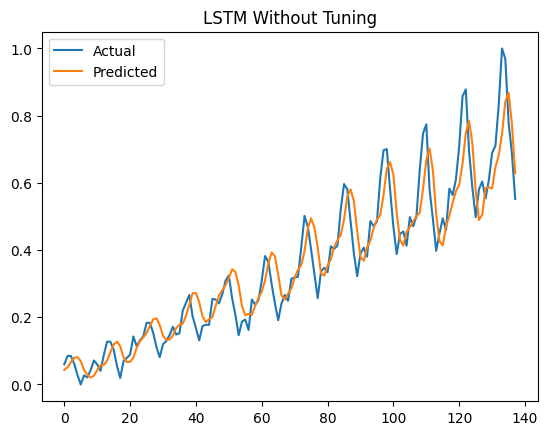

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

data = df['Passengers'].values.reshape(-1,1)

# Scaling
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
def create_data(dataset, time_step=5):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

X, y = create_data(data, 5)

# Reshape
X = X.reshape(X.shape[0], X.shape[1], 1)

# Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(5,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train
history1 = model.fit(X, y, epochs=50, batch_size=16)

# Prediction
pred1 = model.predict(X)

# Graph
plt.figure()
plt.plot(y, label='Actual')
plt.plot(pred1, label='Predicted')
plt.title("LSTM Without Tuning")
plt.legend()
plt.show()


Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1384
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0426
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0205
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0161
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134
Epoch 7/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0126
Epoch 8/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0122
Epoch 9/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0109
Epoch 10/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0109
Epoch 11/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0109
Epoch 12/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0108
Epoch 13/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0108
Epoch 14/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0100
Epoch 15/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100
Epoch 16/80
18/18 ━

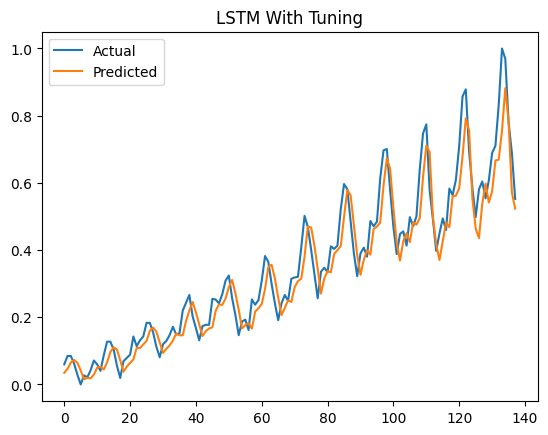

In [2]:
# Tuned Model

model2 = Sequential()
model2.add(LSTM(100, activation='relu', input_shape=(5,1)))
model2.add(Dense(1))

model2.compile(optimizer='adam', loss='mse')

# Train with different parameters
history2 = model2.fit(X, y, epochs=80, batch_size=8)

# Prediction
pred2 = model2.predict(X)

# Graph
plt.figure()
plt.plot(y, label='Actual')
plt.plot(pred2, label='Predicted')
plt.title("LSTM With Tuning")
plt.legend()
plt.show()
